<a href="https://colab.research.google.com/github/mevangelista-alvarado/semana_ingenieria_uagro_2026/blob/main/3_modelo_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

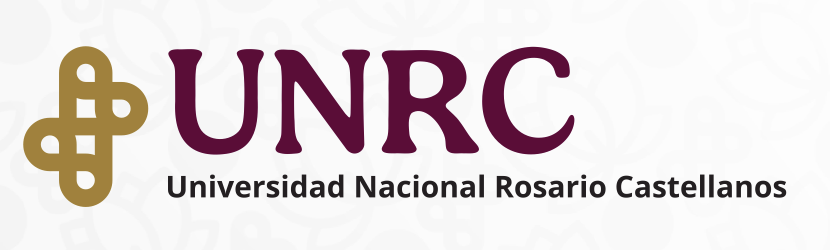

**Miguel Evangelista-Alvarado**.  
**Profesor de la Licenciatura en Ciencia de Datos para Negocios**.  
**Abril de 2026**

# Modelo CNN en Python

## Pre-procesamiento de los datos

### Obtenemos los datos

In [4]:
!wget https://github.com/mevangelista-alvarado/semana_ingenieria_uagro_2026/raw/refs/heads/main/digits.pkl

--2026-04-29 07:19:57--  https://github.com/mevangelista-alvarado/semana_ingenieria_uagro_2026/raw/refs/heads/main/digits.pkl
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mevangelista-alvarado/semana_ingenieria_uagro_2026/refs/heads/main/digits.pkl [following]
--2026-04-29 07:19:57--  https://raw.githubusercontent.com/mevangelista-alvarado/semana_ingenieria_uagro_2026/refs/heads/main/digits.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1857824 (1.8M) [application/octet-stream]
Saving to: ‘digits.pkl’

digits.pkl          100%[===================>]   1.77M  --.-KB/s    in 0.04s   

2026-

### Leemos los datos

In [13]:
import pickle

with open('digits.pkl', 'rb') as f:
    digits = pickle.load(f)

### Dividimos en conjunto de entrenamiento y prueba

In [14]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target,
    test_size=0.2, random_state=42
)

# One-hot encode the target variable
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

### Notemos la longitud del conjunto de entrenamiento y de test

In [15]:
print(X_train.shape)
print(X_test.shape)

(1437, 64)
(360, 64)


### Estandarizar los valores de los píxeles de la imagen

In [16]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Normalizar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

El StandardScaler es utilizado para estandarizar características eliminando la media y escalando a la varianza unitaria.

Esto significa que, después de aplicar el StandardScaler, la media de cada característica (variable) será 0 y la varianza será 1.

### Notamos cómo se ve el primer elemento de la variable `X_train` después de la normalización

In [17]:
X_train[0]

array([ 0.        , -0.34169755, -0.46336049,  0.50836462, -2.54590607,
       -1.03722581, -0.40623424, -0.13101874, -0.06103492, -0.61725402,
        0.30881425,  0.00348328, -2.18152552, -1.35608548, -0.52465505,
       -0.13336005, -0.04991522,  0.12851911,  1.08857992, -0.19343737,
       -1.16010978, -1.27307852, -0.552537  , -0.11409248, -0.03733267,
        0.86365151,  1.13744682, -1.16195968, -1.60835913, -1.28296188,
       -0.62554872, -0.04573894,  0.        ,  1.09151514,  1.34318585,
       -1.12678131, -0.90106555, -1.13185292, -0.81347241,  0.        ,
       -0.06519029,  0.82828946,  1.39981472, -0.82540858,  0.69177178,
        1.17865528, -0.33784246, -0.09403434, -0.03963009,  0.15955797,
        1.14244768,  0.64507954, -1.42282149,  0.68917912,  1.47990131,
       -0.21608405, -0.02638899, -0.30677646, -0.49962244, -0.246272  ,
        0.84804385,  1.05270303,  0.45952251, -0.19710003])

### Redimensionar el tensor a la forma (total, 8, 8)

In [18]:
# Redimensionar el tensor a la forma (total, 8, 8)
X_train = tf.reshape(X_train, (X_train.shape[0], 8, 8))
X_test = tf.reshape(X_test, (X_test.shape[0], 8, 8))

### Notamos cómo se ve el primer elemento de la variable `X_train` después de redimensionar

In [20]:
# Redondeamos para tener una mejor visualizacion
reshaped_tensor =  tf.floor(X_train[0] * 100) / 100
reshaped_tensor

<tf.Tensor: shape=(8, 8), dtype=float64, numpy=
array([[ 0.  , -0.35, -0.47,  0.5 , -2.55, -1.04, -0.41, -0.14],
       [-0.07, -0.62,  0.3 ,  0.  , -2.19, -1.36, -0.53, -0.14],
       [-0.05,  0.12,  1.08, -0.2 , -1.17, -1.28, -0.56, -0.12],
       [-0.04,  0.86,  1.13, -1.17, -1.61, -1.29, -0.63, -0.05],
       [ 0.  ,  1.09,  1.34, -1.13, -0.91, -1.14, -0.82,  0.  ],
       [-0.07,  0.82,  1.39, -0.83,  0.69,  1.17, -0.34, -0.1 ],
       [-0.04,  0.15,  1.14,  0.64, -1.43,  0.68,  1.47, -0.22],
       [-0.03, -0.31, -0.5 , -0.25,  0.84,  1.05,  0.45, -0.2 ]])>

## Red neuronal convolucional

### Modelo CNN

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

# Crear el modelo de CNN
model = Sequential([
    Conv2D(32, kernel_size=(3, 3),
        activation='relu',
        input_shape=(8, 8, 1)
    ),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

Creamos un modelo secuencial de Keras, que es una pila lineal de capas.  

Este modelo incluye:
* Una capa convolucional con 32 filtros, un tamaño de kernel de 3x3, y la función de activación ReLU.
* Una capa de max pooling para reducir el tamaño espacial de la salida.
* Una capa flatten para aplanar los datos antes de pasar a las capas densas.
* Una capa densa con 128 unidades y la función de activación ReLU.
* Una capa de salida densa con 10 unidades (una para cada clase) y la función de activación softmax.

###Compilar el modelo

In [29]:
from tensorflow.keras.optimizers import Adam

# Tasa de aprendizaje deseada
learning_rate = 0.001
adam_optimizer = Adam(learning_rate=learning_rate)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

El optimizador es el algoritmo que ajusta los pesos del modelo en cada iteración para minimizar el error.

Adam es uno de los optimizadores más usados porque:
* Ajusta automáticamente la tasa de aprendizaje por parámetro
* Converge rápido y de forma bastante establ

La función de pérdida (entropía cruzada categórica - `categorical_crossentropy`) mide qué tan mal está prediciendo el modelo.  

$$L = - \Sigma_{i=1}^{K}y_{i}log(\hat{y_i})$$

Dicha función es muy común usarla cuando:
* Tienes clasificación multiclase
* Las etiquetas están en one-hot encoding

Podemos pensar que está función es como una métrica de “distancia probabilística” entre lo esperado y lo predicho.

## Entrenamiento

In [30]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=3,
    validation_split=0.2
)

Epoch 1/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8016 - loss: 0.7141 - val_accuracy: 0.9444 - val_loss: 0.2619
Epoch 2/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9574 - loss: 0.1423 - val_accuracy: 0.9062 - val_loss: 0.3238
Epoch 3/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9739 - loss: 0.0853 - val_accuracy: 0.9514 - val_loss: 0.1590
Epoch 4/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9887 - loss: 0.0487 - val_accuracy: 0.9549 - val_loss: 0.1313
Epoch 5/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9896 - loss: 0.0327 - val_accuracy: 0.9653 - val_loss: 0.1271
Epoch 6/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9922 - loss: 0.0298 - val_accuracy: 0.9792 - val_loss: 0.0685
Epoch 7/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9965 - loss: 0.0192 - val_accuracy: 0.9792 - val_loss: 0.0675
Epoch 8/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0069 - val_accuracy: 0.

Se especifica el número de épocas `epochs`, el tamaño del lote `batch_size` y la proporción de validación `validation_split` para monitorear el rendimiento del modelo durante el entrenamiento.

### Función de pérdida

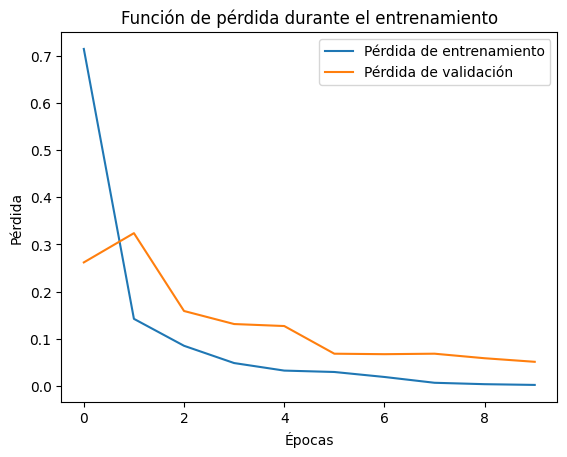

In [31]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.title('Función de pérdida durante el entrenamiento')
plt.show()

### Evaluación

In [32]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {loss}, Accuracy: {accuracy}')

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9833 - loss: 0.0492  
Loss: 0.04916030913591385, Accuracy: 0.9833333492279053


### Matriz de confusión y la sensibilidad (recall)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


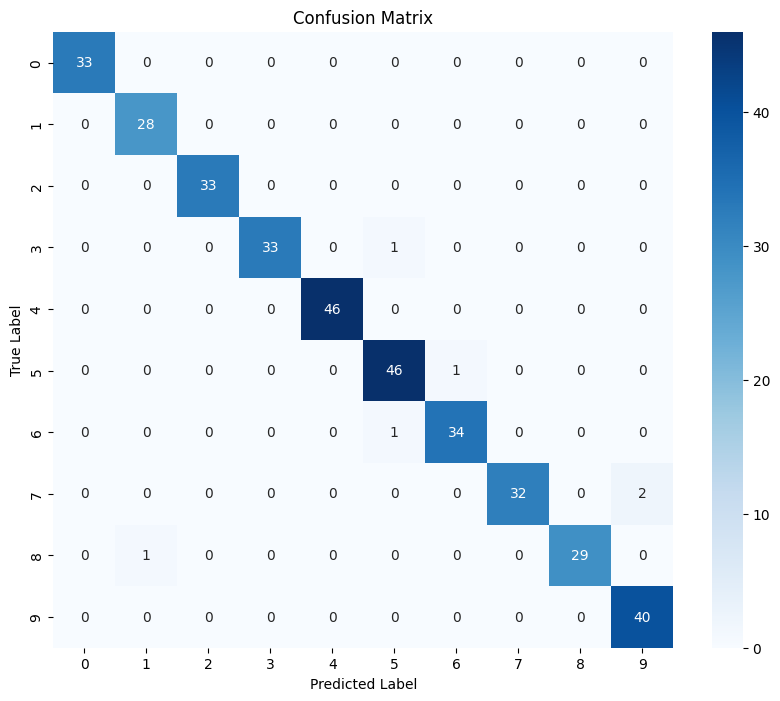

Sensitivity (Recall) for each class:
Class 0: 1.0
Class 1: 1.0
Class 2: 1.0
Class 3: 0.9705882352941176
Class 4: 1.0
Class 5: 0.9787234042553191
Class 6: 0.9714285714285714
Class 7: 0.9411764705882353
Class 8: 0.9666666666666667
Class 9: 1.0


In [34]:
import numpy as np
from sklearn.metrics import confusion_matrix, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
# Convert y_test back to multiclass format
y_test_classes = np.argmax(y_test, axis=1)

conf_matrix = confusion_matrix(y_test_classes, y_pred_classes)
sensitivity = recall_score(y_test_classes, y_pred_classes, average=None)

# Visualizar la matriz de confusión como una imagen de colores
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Mostrar la sensibilidad (recall) para cada clase
print('Sensitivity (Recall) for each class:')
for i in range(10):
    print(f'Class {i}: {sensitivity[i]}')

### Guardamos el modelo

In [35]:
model.save("modelo_cnn.h5")